#Installing Ortools

In [63]:
pip install ortools

Note: you may need to restart the kernel to use updated packages.


#**How to import any Library**

In [64]:
import ortools


In [65]:
from ortools.sat.python import cp_model
model = cp_model.CpModel()
x =model.NewIntVar(0,2,'x')
y =model.NewIntVar(0,2,'y')
z =model.NewIntVar(0,2,'z')
model.add(x != y)
model.add(y != z)
model.add(x != z)
solver = cp_model.CpSolver()

solution_printer = cp_model.VarArraySolutionPrinter([x,y,z])
solver.parameters.enumerate_all_solutions = True
solver.solve(model,solution_printer)

Solution 0, time = 0.00 s
  x = 0   y = 1   z = 2 
Solution 1, time = 0.01 s
  x = 1   y = 0   z = 2 
Solution 2, time = 0.01 s
  x = 0   y = 2   z = 1 
Solution 3, time = 0.01 s
  x = 1   y = 2   z = 0 
Solution 4, time = 0.01 s
  x = 2   y = 0   z = 1 
Solution 5, time = 0.02 s
  x = 2   y = 1   z = 0 


<CpSolverStatus.OPTIMAL: 4>

#**CSP Example # 1**

Define a CSP problem with three variables ('a', 'b', 'c') that can take on values between 1 and 3. We add constraints to the problem to ensure that no two variables can have the same value. We then  call the getSolutions method to find all possible solutions to the problem

In [66]:
from ortools.sat.python import cp_model

# Create the model
model = cp_model.CpModel()

# Define the variables with a domain of {1, 2, 3}
a = model.NewIntVar(1, 3, 'a') #To add variable we use .NewIntVar Method
b = model.NewIntVar(1, 3, 'b')
c = model.NewIntVar(1, 3, 'c')

# Add constraints to ensure all variables have different values
model.Add(a != b) #To add constraints we use .Add Method
model.Add(b != c)
model.Add(a != c)

# Create the solver object that will solve the constraint problem
solver = cp_model.CpSolver()

# Create a solution printer that will print the values of variables a, b, and c
# whenever the solver finds a solution
solution_printer = cp_model.VarArraySolutionPrinter([a, b, c])

# This tells the solver to find and display all possible solutions
# instead of stopping after the first one
solver.parameters.enumerate_all_solutions = True


# ---------------- Solve the problem ----------------

# Solve the model (problem) using the solver
# solution_printer will print each solution found
solver.Solve(model, solution_printer)


# ---------------- Solver Status Codes ----------------

# OPTIMAL means the solver found the best possible solution
print("optimal", cp_model.OPTIMAL)

# FEASIBLE means a valid solution was found, but it may not be the best one
print("Feasible", cp_model.FEASIBLE)

# INFEASIBLE means no solution exists that satisfies all constraints
print("InFeasible", cp_model.INFEASIBLE)

# UNKNOWN means the solver could not determine a solution
# (for example, due to time limits or incomplete search)
print("UNKNOWN", cp_model.UNKNOWN)

Solution 0, time = 0.00 s
  a = 1   b = 2   c = 3 
Solution 1, time = 0.01 s
  a = 2   b = 1   c = 3 
Solution 2, time = 0.01 s
  a = 1   b = 3   c = 2 
Solution 3, time = 0.01 s
  a = 2   b = 3   c = 1 
Solution 4, time = 0.01 s
  a = 3   b = 1   c = 2 
Solution 5, time = 0.01 s
  a = 3   b = 2   c = 1 
optimal CpSolverStatus.OPTIMAL
Feasible CpSolverStatus.FEASIBLE
InFeasible CpSolverStatus.INFEASIBLE
UNKNOWN CpSolverStatus.UNKNOWN


In [67]:
from ortools.sat.python import cp_model

# Map colors to integers
colors = {'Red':1, 'Blue':2, 'Green':3}

# Create model
model = cp_model.CpModel()

# Define variables (integer mapping)
A = model.NewIntVar(1, 3, 'player1')
B = model.NewIntVar(1, 3, 'player2')
C = model.NewIntVar(1, 3, 'player3')

# Add constraints (adjacent regions cannot have same color)
model.Add(A != B)
model.Add(B != C)
model.Add(A != C)

# Solver and solution printer
solver = cp_model.CpSolver()
solution_printer = cp_model.VarArraySolutionPrinter([A,B,C])
solver.parameters.enumerate_all_solutions = True
solver.Solve(model, solution_printer)


Solution 0, time = 0.00 s
  player1 = 1   player2 = 2   player3 = 3 
Solution 1, time = 0.01 s
  player1 = 2   player2 = 1   player3 = 3 
Solution 2, time = 0.01 s
  player1 = 1   player2 = 3   player3 = 2 
Solution 3, time = 0.01 s
  player1 = 2   player2 = 3   player3 = 1 
Solution 4, time = 0.01 s
  player1 = 3   player2 = 1   player3 = 2 
Solution 5, time = 0.01 s
  player1 = 3   player2 = 2   player3 = 1 


<CpSolverStatus.OPTIMAL: 4>

In [68]:
# # Custom class to print feasible solutions
# class FeasibleSolutionPrinter(cp_model.CpSolverSolutionCallback):
#     def __init__(self, variables):
#         cp_model.CpSolverSolutionCallback.__init__(self)
#         self.variables = variables
#         self.solution_count = 0

#     def on_solution_callback(self):
#         self.solution_count += 1
#         print(f"Feasible Solution {self.solution_count}: ", end="")
#         for var in self.variables:
#             print(f"{var.Name()} = {self.Value(var)}", end="  ")
#         print()

# # Enable finding multiple solutions
# solution_printer = FeasibleSolutionPrinter([x, y, z])
# solver.parameters.enumerate_all_solutions = True

# # Solve the model and find all feasible solutions
# status = solver.Solve(model, solution_printer)

# # If no feasible solution was found
# if solution_printer.solution_count == 0:
#     print("No feasible solution found.")

#Example # 1 (Lab Manual)

###**Scenario :**
A manager is assigning shifts to three employees: Alice, Bob, and Charlie. Each employee must be assigned a shift, and there are three available shifts (0, 1, or 2).

However, there is one condition:

Alice and Bob cannot be assigned the same shift (to ensure proper coverage).

In [69]:
from ortools.sat.python import cp_model

model = cp_model.CpModel()
alice = model.NewIntVar(0, 2, 'x')
bob= model.NewIntVar(0, 2, 'y')
charlie= model.NewIntVar(0, 2, 'z')

c1=model.Add(alice!=bob)
c2=model.Add(bob!=0)

solver=cp_model.CpSolver()
solver.solve(model)


<CpSolverStatus.OPTIMAL: 4>

In [70]:
#Import the google ortools library to solve the csp problem
from ortools.sat.python import cp_model

# Declare the model and bind it with CpModel which is already present in ortools library
model = cp_model.CpModel()

#Declaring the set of variables for csp
num_vals = 3
x = model.new_int_var(0, num_vals - 1, "x")
y = model.new_int_var(0, num_vals - 1, "y")
z = model.new_int_var(0, num_vals - 1, "z")

#Declaring Constraints
model.add(x != y)
model.add(y != z)

#output:-
# <ortools.sat.python.cp_model.Constraint at 0x7ec6e989bd50>


# # Create the solver
solver = cp_model.CpSolver()
solution_printer = cp_model.VarArraySolutionPrinter([x, y, z])
solver.parameters.enumerate_all_solutions = True

# Solve the problem
solver.Solve(model, solution_printer)


Solution 0, time = 0.00 s
  x = 0   y = 1   z = 2 
Solution 1, time = 0.01 s
  x = 1   y = 0   z = 2 


Solution 2, time = 0.01 s
  x = 1   y = 0   z = 1 
Solution 3, time = 0.01 s
  x = 1   y = 2   z = 1 
Solution 4, time = 0.01 s
  x = 0   y = 2   z = 1 
Solution 5, time = 0.02 s
  x = 0   y = 2   z = 0 
Solution 6, time = 0.02 s
  x = 0   y = 1   z = 0 
Solution 7, time = 0.03 s
  x = 1   y = 2   z = 0 
Solution 8, time = 0.03 s
  x = 2   y = 0   z = 2 
Solution 9, time = 0.03 s
  x = 2   y = 0   z = 1 
Solution 10, time = 0.04 s
  x = 2   y = 1   z = 0 
Solution 11, time = 0.04 s
  x = 2   y = 1   z = 2 


<CpSolverStatus.OPTIMAL: 4>

###**Other methods**
**cp_model.OPTIMAL**: A solution is found, and it is the best possible solution.

**cp_model.FEASIBLE**: A valid solution is found, but it may not be optimal.

**cp_model.INFEASIBLE**: No solution satisfies all constraints.

**cp_model.UNKNOWN**: The solver could not determine a solution.

In [71]:
from ortools.sat.python import cp_model

# Create the model
model = cp_model.CpModel()

# Define variables with domain {0, 1, 2}
num_vals = 3
x = model.NewIntVar(0, num_vals - 1, "x")
y = model.NewIntVar(0, num_vals - 1, "y")
z = model.NewIntVar(0, num_vals - 1, "z")

# Add constraint: x != y
model.Add(x != y)
model.Add(y != z)
model.Add(x != z)
model.Add(x != 0) # Additional constraint to ensure x is not 0
model.Add(y != 0) # Additional constraint to ensure y is not 0
model.Add(z != 0) # Additional constraint to ensure z is not 0

# Create solver
solver = cp_model.CpSolver()

# Solve the model
status = solver.Solve(model)
print(status)
# Display solver status in a readable way
status_mapping = {
    cp_model.OPTIMAL: "OPTIMAL",
    cp_model.FEASIBLE: "FEASIBLE",
    cp_model.INFEASIBLE: "INFEASIBLE",
    cp_model.UNKNOWN: "UNKNOWN"
}

print(f"Solver Status: {status_mapping.get(status, 'UNKNOWN')} ({status})")

# Print solution if feasible or optimal
if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
    print(f"x = {solver.Value(x)}")
    print(f"y = {solver.Value(y)}")
    print(f"z = {solver.Value(z)}")
else:
    print("No feasible solution found.")


CpSolverStatus.INFEASIBLE
Solver Status: INFEASIBLE (CpSolverStatus.INFEASIBLE)
No feasible solution found.


In [72]:
from ortools.sat.python import cp_model

# Create the model
model = cp_model.CpModel()

# Define variables with domain {0, 1, 2}
num_vals = 3
x = model.NewIntVar(0, num_vals - 1, "x")
y = model.NewIntVar(0, num_vals - 1, "y")
z = model.NewIntVar(0, num_vals - 1, "z")

# Add constraints that conflict
model.Add(x != y)    # x and y must be different
model.Add(x == y)    # x and y must be same → conflict
model.Add(z == 0)    # extra constraint for demonstration

# Create solver
solver = cp_model.CpSolver()

# Solve the model
status = solver.Solve(model)
print(status)

# Display solver status in a readable way
status_mapping = {
    cp_model.OPTIMAL: "OPTIMAL",
    cp_model.FEASIBLE: "FEASIBLE",
    cp_model.INFEASIBLE: "INFEASIBLE",
    cp_model.UNKNOWN: "UNKNOWN"
}

print(f"Solver Status: {status_mapping.get(status, 'UNKNOWN')} ({status})")

# Print solution if feasible or optimal
if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
    print(f"x = {solver.Value(x)}")
    print(f"y = {solver.Value(y)}")
    print(f"z = {solver.Value(z)}")
else:
    print("No feasible solution found.")


CpSolverStatus.INFEASIBLE
Solver Status: INFEASIBLE (CpSolverStatus.INFEASIBLE)
No feasible solution found.


In [73]:
#Import the google ortools library to solve the csp problem
from ortools.sat.python import cp_model

# Declare the model and bind it with CpModel which is already present in ortools library
model = cp_model.CpModel()

#Declaring the set of variables for csp
num_vals = 3
x = model.new_int_var(0, num_vals - 1, "x")
y = model.new_int_var(0, num_vals - 1, "y")
z = model.new_int_var(0, num_vals - 1, "z")

#Declaring Constraints
model.add(x != y)

#output:-
# <ortools.sat.python.cp_model.Constraint at 0x7ec6e989bd50>

solver = cp_model.CpSolver()
status = solver.solve(model)
if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
    print(f"x = {solver.value(x)}")
    print(f"y = {solver.value(y)}")
    print(f"z = {solver.value(z)}")
else:
    print("No solution found.")


x = 1
y = 0
z = 0


##**Example #2**

###**rough understanding of below task code**

In [74]:
l=[[1 for _ in range(10)] for _ in range(10)]
l

[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]

In [75]:
size=4
import random
a= (random.randint(0, size-1), random.randint(0, size-1))
a

(3, 3)

In [76]:
10**2
4**2

16

1) A robotic drone operates in a grid-based environment where it can only move diagonally due to terrain constraints. Given the drone's starting position (Point A) and its destination (Point B), the AI system must determine the shortest direct path using Pythagoras' theorem.

In [77]:
import math      # Used for mathematical operations like square root
import random    # Used to generate random start and goal positions
from ortools.sat.python import cp_model   # Import OR-Tools CP-SAT solver

# Class representing the grid environment
class GridEnvironment:
    def __init__(self, size):
        self.size = size   # Size of the grid (e.g., 10x10)

        # Create a grid filled with zeros
        self.grid = [[0 for _ in range(size)] for _ in range(size)]

        # Randomly generate the start position inside the grid
        self.start = (random.randint(0, size-1), random.randint(0, size-1))

        # Randomly generate the goal position inside the grid
        self.goal = (random.randint(0, size-1), random.randint(0, size-1))

    # Function to solve the CSP problem
    def solve_csp(self):

        # Create a CSP model
        model = cp_model.CpModel()

        # Extract x and y coordinates of start and goal positions
        x1, y1 = self.start
        x2, y2 = self.goal

        # -------- Variables --------

        # Calculate horizontal distance between start and goal
        a = abs(x2 - x1)

        # Calculate vertical distance between start and goal
        b = abs(y2 - y1)

        # Create CSP variable for the hypotenuse (distance)
        # Range is from 0 to twice the grid size
        c = model.NewIntVar(0, self.size * 2, 'c')

        # Variables to store squared values
        a_sq = model.NewIntVar(0, self.size**2, 'a_sq')
        b_sq = model.NewIntVar(0, self.size**2, 'b_sq')
        c_sq = model.NewIntVar(0, self.size**2, 'c_sq')

        # -------- Constraints --------

        # Define a_sq = a * a
        model.AddMultiplicationEquality(a_sq, [a, a])

        # Define b_sq = b * b
        model.AddMultiplicationEquality(b_sq, [b, b])

        # Define c_sq = c * c
        model.AddMultiplicationEquality(c_sq, [c, c])

        # Apply Pythagorean theorem: c² = a² + b²
        model.Add(c_sq == a_sq + b_sq)

        # -------- Solve the model --------

        # Create solver object
        solver = cp_model.CpSolver()

        # Solve the CSP model
        status = solver.Solve(model)

        # If a valid solution is found
        if status == cp_model.FEASIBLE or status == cp_model.OPTIMAL:

            # Return base, height, and calculated hypotenuse
            return a, b, solver.Value(c)

            # (This line will never execute because return is above)
            print(a, b, solver.Value(c))

        # If solver fails, calculate distance using normal math formula
        return a, b, math.sqrt(a**2 + b**2)


    # Function to display results
    def display(self):

        # Print start and goal positions
        print(f"Start Position: {self.start}")
        print(f"Goal Position: {self.goal}")

        # Solve the CSP problem and get distances
        a, b, c = self.solve_csp()

        # Display calculated distances
        print(f"Calculated Distances: Base={a}, Height={b}, Hypotenuse={c:.2f}")


# -------- Simulation --------

# Create a grid environment of size 10x10
environment = GridEnvironment(4)

# Run the simulation and display results
environment.display()

Start Position: (2, 2)
Goal Position: (1, 2)
Calculated Distances: Base=1, Height=0, Hypotenuse=1.00



#Drone Example
A surveillance drone is deployed in a disaster-affected city area represented as a grid map. Each cell in the grid represents a location where the drone can either fly safely (1) or encounter an obstacle such as damaged buildings or restricted zones (0).
The drone starts from a base station (Start point) and must reach a target location (Goal point) to deliver emergency supplies or capture aerial images. However, due to obstacles in the environment, the drone cannot move through blocked cells.
The drone is capable of moving in eight possible directions: up, down, left, right, and the four diagonal directions. Each movement has a cost, and diagonal movements have a slightly higher cost calculated using Pythagoras’ theorem.
To determine the shortest and most efficient path, the system uses the Uniform Cost Search (UCS) algorithm. The algorithm explores the grid by always expanding the node with the lowest accumulated travel cost, ensuring that the drone finds the optimal path from the start location to the destination while avoiding obstacles.

In [78]:
import heapq   # Used to implement the priority queue for UCS
import math    # Used for mathematical calculations (e.g., square root)

class DronePathPlanner:
    def __init__(self, grid, start, goal):
        self.grid = grid   # 2D grid map where 1 = open cell and 0 = obstacle
        self.start = start # Starting position of the drone (x, y)
        self.goal = goal   # Goal/destination position (x, y)

        # Get number of rows and columns in the grid
        self.rows = len(grid)
        self.cols = len(grid[0])

        # Possible movement directions
        self.directions = [
            (-1,0),(1,0),(0,-1),(0,1),   # straight moves: up, down, left, right
            (-1,-1),(-1,1),(1,-1),(1,1)  # diagonal moves
        ]

        # Cost of diagonal movement calculated using Pythagoras theorem
        self.cost = math.sqrt(2)

    def is_valid(self, x, y):
        """Check if the cell is inside the grid and not an obstacle."""

        # Check if coordinates are within grid boundaries
        # and the cell is open (value = 1)
        return 0 <= x < self.rows and 0 <= y < self.cols and self.grid[x][y] == 1


    def ucs(self):
        """Uniform Cost Search to find the shortest path."""

        # Priority queue stores tuples (cost, position)
        priority_queue = [(0, self.start)]

        visited = set()  # Keep track of visited nodes

        # Dictionary to store the parent of each node (for path reconstruction)
        parent = {self.start: None}

        # Continue searching until queue becomes empty
        while priority_queue:

            # Get the node with the lowest cost
            cost, (x, y) = heapq.heappop(priority_queue)

            # Skip the node if it was already visited
            if (x, y) in visited:
                continue

            # Mark node as visited
            visited.add((x, y))

            # If goal is reached, reconstruct and return the path
            if (x, y) == self.goal:
                return self.reconstruct_path(parent)

            # Explore all possible movement directions
            for dx, dy in self.directions:

                # Calculate new position
                new_x, new_y = x + dx, y + dy

                # Check if new position is valid and not visited
                if self.is_valid(new_x, new_y) and (new_x, new_y) not in visited:

                    # Add the new position to the priority queue with updated cost
                    heapq.heappush(priority_queue, (cost + self.cost, (new_x, new_y)))

                    # Store parent to track the path later
                    parent[(new_x, new_y)] = (x, y)

        # If no path is found
        return None


    def reconstruct_path(self, parent):
        """Reconstruct the path from goal to start."""

        path = []  # List to store the final path

        node = self.goal  # Start from the goal node

        # Follow the parent nodes until reaching the start node
        while node:
            path.append(node)
            node = parent[node]

        # Reverse the path so it goes from start → goal
        return path[::-1]


# ---------------- Grid Definition ----------------

# Define a 5x5 grid (1 = open cell, 0 = obstacle)
grid = [
    [1, 1, 1, 1, 1],
    [1, 0, 1, 0, 1],
    [1, 1, 1, 1, 1],
    [1, 0, 1, 0, 1],
    [1, 1, 1, 1, 1]
]

# Define start and goal positions
start = (0, 0)  # Top-left corner
goal = (4, 4)   # Bottom-right corner


# ---------------- Run the Algorithm ----------------

# Create the drone path planner object
drone = DronePathPlanner(grid, start, goal)

# Run Uniform Cost Search to find the shortest path
shortest_path = drone.ucs()


# ---------------- Print Result ----------------

# If a valid path is found, print it
if shortest_path:
    print("Shortest Path:", shortest_path)
else:
    print("No valid path found!")

Shortest Path: [(0, 0), (0, 1), (1, 0), (2, 0), (2, 1), (3, 0), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]


| Step | Current Node | Cost So Far | Expanded Nodes (Possible Moves) | Queue After Expansion                           |
| ---- | ------------ | ----------- | ------------------------------- | ----------------------------------------------- |
| 1    | (0,0)        | 0           | (1,0), (0,1), (1,1)             | [(1.41,(1,1)), (1.41,(1,0)), (1.41,(0,1))]      |
| 2    | (1,1)        | 1.41        | (2,2), (2,1), (1,2)             | [(2.82,(2,2)), (2.82,(2,1)), (2.82,(1,2)), ...] |
| 3    | (2,2)        | 2.82        | (3,3), (3,2), (2,3)             | [(4.23,(3,3)), (4.23,(3,2)), (4.23,(2,3)), ...] |
| 4    | (3,3)        | 4.23        | (4,4), (4,3), (3,4)             | [(5.64,(4,4)), (5.64,(4,3)), (5.64,(3,4)), ...] |
| 5    | (4,4)        | 5.64        | Goal reached                    | Stop                                            |


#**Example #3**

#**n Queens**

In [79]:
import sys
import time
from ortools.sat.python import cp_model

In [80]:
model = cp_model.CpModel()

In [81]:
# There are `board_size` number of variables, one for a queen in each column
# of the board. The value of each variable is the row that the queen is in.
board_size = 8
queens = [model.new_int_var(0, board_size - 1, f"x_{i}") for i in range(board_size)]

In [82]:
# All rows must be different.
model.add_all_different(queens)

# No two queens can be on the same diagonal.
model.add_all_different(queens[i] + i for i in range(board_size))
model.add_all_different(queens[i] - i for i in range(board_size))

In [83]:
# ------------------- Diagonal Constraint Setup for N-Queens -------------------

# Create a list to hold the "diagonal 1" variables.
# This represents the diagonals that go from top-left to bottom-right.
diag1 = []

# Loop over each queen (column index) from 0 to board_size-1
for i in range(board_size):

    # Create a new integer variable for the i-th queen's diagonal
    # q1 will store the value of (row position + column index)
    # Row position is queens[i], column index is i
    # Range: 0 to 2 * board_size because the maximum sum of row + column = (N-1) + (N-1) = 2N-2
    q1 = model.NewIntVar(0, 2 * board_size, 'diag1_%i' % i)

    # Add this variable to the list of diagonal variables
    diag1.append(q1)

    # Add a constraint linking q1 to the queen's row and column
    # This ensures that q1 accurately represents the diagonal number for this queen
    # Concept: All cells on the same top-left → bottom-right diagonal have the same value of row + column
    model.Add(q1 == queens[i] + i)

# Later in the code, we would usually enforce:
# model.AddAllDifferent(diag1)
# This ensures that no two queens share the same top-left → bottom-right diagonal,
# which prevents them from attacking each other diagonally.

In [84]:
model.AddAllDifferent(diag1)

In [85]:
import time
from ortools.sat.python import cp_model

# ------------------- N-Queens Solution Printer -------------------
# This class is a callback for OR-Tools solver that prints each solution as it is found.
# Inherits from CpSolverSolutionCallback, which allows code to run automatically
# every time the solver finds a feasible solution.
class NQueenSolutionPrinter(cp_model.CpSolverSolutionCallback):
    """Print intermediate N-Queens solutions with a visual board and timing info."""

    # ------------------- Initialization -------------------
    def __init__(self, queens: list[cp_model.IntVar]):
        # Initialize the base class
        cp_model.CpSolverSolutionCallback.__init__(self)

        # Store the list of queen variables
        # queens[i] = row position of the queen in column i
        self.__queens = queens

        # Counter to track number of solutions found
        self.__solution_count = 0

        # Store the starting time to measure elapsed time for each solution
        self.__start_time = time.time()

    # ------------------- Solution Count Property -------------------
    @property
    def solution_count(self) -> int:
        """
        Getter for number of solutions found so far.
        Allows accessing with: printer.solution_count
        """
        return self.__solution_count

    # ------------------- Callback Function -------------------
    def on_solution_callback(self):
        """
        This function is automatically called by OR-Tools
        each time a solution is found.
        It prints solution number, elapsed time, and visual board.
        """

        # Get the current time
        current_time = time.time()

        # Print the solution number and time elapsed since start
        print(
            f"Solution {self.__solution_count}, "
            f"time = {current_time - self.__start_time:.2f} s"
        )

        # Increment the solution counter for the next solution
        self.__solution_count += 1

        # Get the number of queens (board size)
        all_queens = range(len(self.__queens))

        # ------------------- Print the Board -------------------
        for i in all_queens:  # Loop over each row
            for j in all_queens:  # Loop over each column
                # Check if the queen in column j is in row i
                if self.value(self.__queens[j]) == i:
                    print("Q", end=" ")  # Place a Queen
                else:
                    print("_", end=" ")  # Empty square
            print()  # Move to the next row
        print()  # Blank line between solutions for clarity

In [86]:
solver = cp_model.CpSolver()
solution_printer = NQueenSolutionPrinter(queens)
solver.parameters.enumerate_all_solutions = True
solver.solve(model, solution_printer)

Solution 0, time = 0.02 s
_ _ _ _ Q _ _ _ 
_ _ _ _ _ _ Q _ 
_ Q _ _ _ _ _ _ 
_ _ _ _ _ Q _ _ 
_ _ Q _ _ _ _ _ 
Q _ _ _ _ _ _ _ 
_ _ _ _ _ _ _ Q 
_ _ _ Q _ _ _ _ 

Solution 1, time = 0.02 s
_ _ _ _ Q _ _ _ 
_ _ _ _ _ _ Q _ 
_ Q _ _ _ _ _ _ 
_ _ _ _ _ Q _ _ 
_ _ Q _ _ _ _ _ 
Q _ _ _ _ _ _ _ 
_ _ _ Q _ _ _ _ 
_ _ _ _ _ _ _ Q 

Solution 2, time = 0.02 s
_ _ Q _ _ _ _ _ 
_ _ _ _ _ _ Q _ 
_ Q _ _ _ _ _ _ 
_ _ _ _ _ _ _ Q 
_ _ _ _ _ Q _ _ 
_ _ _ Q _ _ _ _ 
Q _ _ _ _ _ _ _ 
_ _ _ _ Q _ _ _ 

Solution 3, time = 0.03 s
_ _ Q _ _ _ _ _ 
_ _ _ _ _ _ Q _ 
_ Q _ _ _ _ _ _ 
_ _ _ _ _ _ _ Q 
_ _ _ _ Q _ _ _ 
Q _ _ _ _ _ _ _ 
_ _ _ Q _ _ _ _ 
_ _ _ _ _ Q _ _ 

Solution 4, time = 0.03 s
_ _ _ _ Q _ _ _ 
_ _ _ _ _ _ Q _ 
_ Q _ _ _ _ _ _ 
_ _ _ Q _ _ _ _ 
_ _ _ _ _ _ _ Q 
Q _ _ _ _ _ _ _ 
_ _ Q _ _ _ _ _ 
_ _ _ _ _ Q _ _ 

Solution 5, time = 0.03 s
_ _ _ _ _ Q _ _ 
_ _ _ _ _ _ _ Q 
_ Q _ _ _ _ _ _ 
_ _ _ Q _ _ _ _ 
Q _ _ _ _ _ _ _ 
_ _ _ _ _ _ Q _ 
_ _ _ _ Q _ _ _ 
_ _ Q _ _ _ _ _ 

Solution 6, time = 0.0

<CpSolverStatus.OPTIMAL: 4>

#**OrTools Methodsss**

###**Other methods**
**cp_model.OPTIMAL**: A solution is found, and it is the best possible solution.

**cp_model.FEASIBLE**: A valid solution is found, but it may not be optimal.

**cp_model.INFEASIBLE**: No solution satisfies all constraints.

**cp_model.UNKNOWN**: The solver could not determine a solution.

In [87]:
print("optimal",cp_model.OPTIMAL)
print("Feasible",cp_model.FEASIBLE)
print("InFeasible",cp_model.INFEASIBLE)
print("UNKNOWN",cp_model.UNKNOWN)

optimal CpSolverStatus.OPTIMAL
Feasible CpSolverStatus.FEASIBLE
InFeasible CpSolverStatus.INFEASIBLE
UNKNOWN CpSolverStatus.UNKNOWN


#Ort_TOOLs Methods

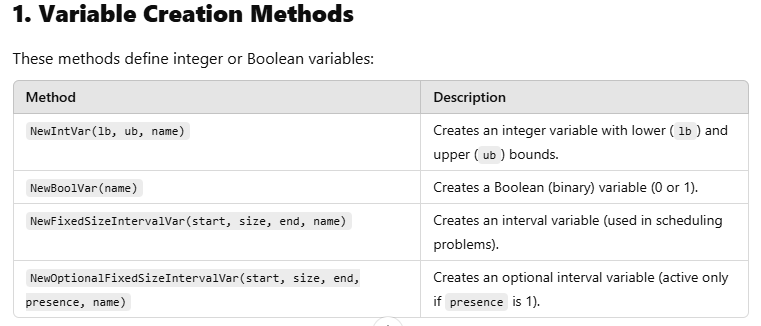

**Integer Variables (NewIntVar)** → Represents a variable that can take values within a specific integer range (e.g., x ∈ [0, 10]).

**Boolean Variables (NewBoolVar)** → A special case of integer variables that can only be 0 or 1, used for binary decisions.

**Interval Variables (NewFixedSizeIntervalVar)** → Defines a fixed-length time interval (e.g., a task with a known duration).

**Optional Interval Variables (NewOptionalFixedSizeIntervalVar)**→ Similar to interval variables but only active if a Boolean variable is 1 (e.g., conditional scheduling tasks).

In [92]:
from ortools.sat.python import cp_model

# ---------------- Create model ----------------
model = cp_model.CpModel()

# ---------------- Integer Variables ----------------
x = model.NewIntVar(0, 10, 'x')
y = model.NewIntVar(-5, 5, 'y')

# ---------------- Boolean Variables ----------------
b1 = model.NewBoolVar('b1')
b2 = model.NewBoolVar('b2')

# Example constraint: x + y = 5
model.Add(x + y == 6)

# ---------------- Interval Variable ----------------
# Used for scheduling tasks with a start and fixed duration
start = model.NewIntVar(0, 10, 'start')  # Start time of the task
duration = 5  # Fixed duration

# Create a standard interval variable (always active)
interval = model.NewFixedSizeIntervalVar(start, duration, 'interval_task')

# ---------------- Optional Interval Variable ----------------
# Only exists if boolean b1 is True (1)
optional_interval = model.NewOptionalFixedSizeIntervalVar(start, duration, b1, 'optional_task')

# ---------------- Solve model ----------------
solver = cp_model.CpSolver()
status = solver.Solve(model)

# ---------------- Print values ----------------
if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
    print("Integer Variables:")
    print("x =", solver.Value(x))
    print("y =", solver.Value(y))

    print("\nBoolean Variables:")
    print("b1 =", solver.Value(b1))
    print("b2 =", solver.Value(b2))

    print("\nInterval Variable:")
    print("Start =", solver.Value(start))
    print("Duration =", duration)
    print("End =", solver.Value(start) + duration)  # End time

    print("\nOptional Interval Variable:")
    # Only print if b1 is 1
    if solver.Value(b1) == 1:
        print("Optional task is active")
        print("Start =", solver.Value(start))
        print("Duration =", duration)
        print("End =", solver.Value(start) + duration)
    else:
        print("Optional task is inactive (b1=0)")
else:
    print("No solution found!")

Integer Variables:
x = 6
y = 0

Boolean Variables:
b1 = 0
b2 = 0

Interval Variable:
Start = 0
Duration = 5
End = 5

Optional Interval Variable:
Optional task is inactive (b1=0)


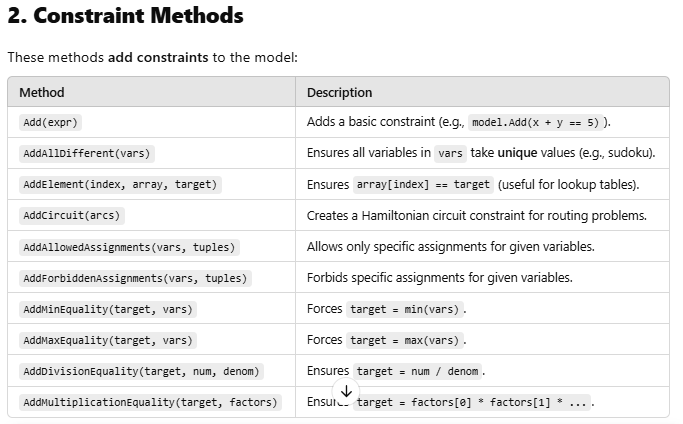

1. Add(expr)
✅ What? Adds a mathematical constraint (e.g., an equation or inequality).
🎯 Why? To restrict variable values based on conditions (e.g., x + y ≤ 10).

2. AddAllDifferent(vars)
✅ What? Ensures that all given variables have distinct values.
🎯 Why? Used in Sudoku, scheduling, and assignment problems where uniqueness is required.

3. AddElement(index, array, target)
✅ What? Forces target = array[index], acting as an array lookup constraint.
🎯 Why? Useful when the value of a variable depends on an indexed list (e.g., cost tables).

4. AddCircuit(arcs)
✅ What? Defines a Hamiltonian circuit (a cycle visiting all nodes exactly once).
🎯 Why? Used in traveling salesman and routing problems.

5. AddAllowedAssignments(vars, tuples)
✅ What? Allows only specified value combinations for given variables.
🎯 Why? Used in constraint satisfaction problems to enforce allowed scenarios.

6. AddForbiddenAssignments(vars, tuples)
✅ What? Prevents certain value combinations for given variables.
🎯 Why? Used to avoid invalid states in scheduling or logic constraints.

7. AddMinEquality(target, vars)
✅ What? Ensures target = min(vars), setting target to the smallest variable value.
🎯 Why? Used in min-cost selection, minimum processing time, etc.

8. AddMaxEquality(target, vars)
✅ What? Ensures target = max(vars), setting target to the largest variable value.
🎯 Why? Used in maximum load balancing, scheduling, or optimization problems.

9. AddDivisionEquality(target, num, denom)
✅ What? Ensures target = num / denom, performing integer division.
🎯 Why? Used in resource allocation, batch processing, or grouped constraints.

10. AddMultiplicationEquality(target, factors)
✅ What? Ensures target = factors[0] * factors[1] * ..., enforcing a multiplication relationship.
🎯 Why? Useful for cost calculations, scaling factors, and product constraints.



In [93]:
from ortools.sat.python import cp_model

# Create model
model = cp_model.CpModel()

# Define variables
x = model.NewIntVar(0, 10, "x")
y = model.NewIntVar(0, 10, "y")
z = model.NewIntVar(0, 10, "z")

# Applying constraints
model.Add(x + y <= 10)
model.AddAllDifferent([x, y, z])

# Allowed combinations for x,y
model.AddAllowedAssignments([x, y], [(1, 2), (3, 4)])

# Forbidden combinations
model.AddForbiddenAssignments([x, y], [(1, 1), (2, 2)])

# Min and Max targets (separate variables)
min_target = model.NewIntVar(0, 10, "min_target")
max_target = model.NewIntVar(0, 10, "max_target")

model.AddMinEquality(min_target, [x, y, z])
model.AddMaxEquality(max_target, [x, y, z])

# Division constraint
num = model.NewIntVar(1, 10, "num")
denom = model.NewIntVar(1, 5, "denom")
div_target = model.NewIntVar(0, 10, "div_target")
model.AddDivisionEquality(div_target, num, denom)

# Multiplication constraint
factors = [model.NewIntVar(1, 5, f"f{i}") for i in range(2)]
prod_target = model.NewIntVar(1, 25, "prod_target")
model.AddMultiplicationEquality(prod_target, factors)

# Solver
solver = cp_model.CpSolver()
status = solver.Solve(model)

# Output results if feasible
if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:

    print("Solution Found\n")

    print("x =", solver.Value(x))
    print("y =", solver.Value(y))
    print("z =", solver.Value(z))

    print("\nMinimum value =", solver.Value(min_target))
    print("Maximum value =", solver.Value(max_target))

    print("\nDivision result =", solver.Value(div_target))
    print("Numerator =", solver.Value(num))
    print("Denominator =", solver.Value(denom))

    print("\nProduct result =", solver.Value(prod_target))
    print("Factors =", [solver.Value(f) for f in factors])

else:
    print("No feasible solution found.")

Solution Found

x = 1
y = 2
z = 0

Minimum value = 0
Maximum value = 2

Division result = 1
Numerator = 1
Denominator = 1

Product result = 1
Factors = [1, 1]
